# Notebook 10c: EfficientNetB3 — Proper 18-Class Evaluation

Sequential Transfer Learning for Medicinal Plant Identification
Student: Hari (3146279) | BSc Software Engineering | University of Stirling

NB06 evaluation had a `shuffle=False` bug causing only 5 of 18 classes to appear
in the validation set. This notebook re-evaluates the saved EfficientNetB3 model
on all 18 classes to get the correct accuracy and per-species metrics.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU!")

Mounted at /content/drive
TensorFlow: 2.19.0
GPU: /physical_device:GPU:0


In [2]:
# ── Configuration ──
IMG_SIZE = (300, 300)  # EfficientNetB3 native resolution
BATCH_SIZE = 16
SEED = 42

DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "efficientnet_eval_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

DROP_CLASSES = ['Trifolium Repens', 'Trifolium_Repens',
                'Ziziphus mauritiana', 'Ziziphus_mauritiana']

print(f"Project dir: {PROJECT_DIR}")
print(f"Results dir: {RESULTS_DIR}")

Project dir: /content/drive/MyDrive/MedicinalPlant_Dissertation
Results dir: /content/drive/MyDrive/MedicinalPlant_Dissertation/efficientnet_eval_results


## 1. Load Dataset 5 (18 classes)

In [3]:
def find_image_directory(base_dir):
    """Walk directory tree to find folder containing class subdirectories with images."""
    if not os.path.exists(base_dir):
        return None
    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if not dirs:
            continue
        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            sample_files = os.listdir(sample_dir)
            has_images = any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in sample_files)
            if has_images:
                return root
    return None

# Find Dataset 5
print("Finding Dataset 5 (SIMPD)...")
dataset5_path = None
for p in [os.path.join(DATA_DIR, "dataset5"),
          os.path.join(DATA_DIR, "Dataset 5"),
          os.path.join(DATA_DIR, "SIMPD")]:
    if os.path.exists(p):
        found = find_image_directory(p)
        if found:
            dataset5_path = found
            break

if dataset5_path is None:
    dataset5_path = find_image_directory(DATA_DIR)

if dataset5_path is None:
    raise FileNotFoundError("Dataset 5 not found!")
print(f"Dataset 5 found: {dataset5_path}")

# Get all classes
all_classes = sorted([
    d for d in os.listdir(dataset5_path)
    if os.path.isdir(os.path.join(dataset5_path, d)) and not d.startswith('.')
])
print(f"All classes: {len(all_classes)}")

# Filter to 18 classes
keep_classes = [c for c in all_classes if c not in DROP_CLASSES]
dropped = [c for c in all_classes if c in DROP_CLASSES]
print(f"Dropping {len(dropped)} classes: {dropped}")
print(f"Keeping {len(keep_classes)} classes")

# Create filtered dataset directory
filtered_path = "/content/eval_efficientnet_18class"
if os.path.exists(filtered_path):
    shutil.rmtree(filtered_path)
os.makedirs(filtered_path)
for c in keep_classes:
    shutil.copytree(os.path.join(dataset5_path, c), os.path.join(filtered_path, c))

# Load validation set — NO shuffle=False bug this time
val_ds = tf.keras.utils.image_dataset_from_directory(
    filtered_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    shuffle=True  # ensures all 18 classes appear in validation
)

class_names = sorted(os.listdir(filtered_path))
NUM_CLASSES = len(class_names)
print(f"\nValidation set loaded: {NUM_CLASSES} classes")
print(f"Val batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

# Verify all classes present
label_counts = {}
for _, labels in val_ds:
    for l in labels.numpy():
        label_counts[int(l)] = label_counts.get(int(l), 0) + 1
print(f"Unique classes in val set: {len(label_counts)}")
total_samples = sum(label_counts.values())
print(f"Total samples: {total_samples}")
for idx in sorted(label_counts.keys()):
    print(f"  {class_names[idx]:35s} {label_counts[idx]:4d} samples")

Finding Dataset 5 (SIMPD)...
Dataset 5 found: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset5/SIMPD V1 South Indian Medicinal Plants dataset (Version 1)
All classes: 20
Dropping 2 classes: ['Trifolium Repens', 'Ziziphus mauritiana']
Keeping 18 classes
Found 2313 files belonging to 18 classes.
Using 462 files for validation.

Validation set loaded: 18 classes
Val batches: 29
Unique classes in val set: 18
Total samples: 462
  Abutilon Indicum                      27 samples
  Aloe barbadensis miller               21 samples
  Calotropis gigantea                   18 samples
  Canna indica                          29 samples
  Cissus quadrangularis                 31 samples
  Curcuma longa                         24 samples
  Eclipta prostrate                     45 samples
  Eichhornia Crassipes                  48 samples
  Hibiscus Rosasinensis                 22 samples
  Ixora coccinea                        20 samples
  Justica adhatoda                      19 samp

## 2. Load EfficientNetB3 Model

In [4]:
model_path = os.path.join(MODEL_DIR, "improved_model.keras")
print(f"Loading model: {model_path}")

model = None

# Attempt 1: direct load
for kw in [dict(), dict(compile=False), dict(compile=False, safe_mode=False)]:
    try:
        model = keras.models.load_model(model_path, **kw)
        print(f"  Loaded with load_model({kw})")
        break
    except Exception as e:
        print(f"  load_model failed ({kw}): {e}")

# Attempt 2: rebuild from .keras ZIP
if model is None:
    print("\n  Attempting rebuild from .keras archive...")
    weights_tmp = os.path.join(MODEL_DIR, '_temp_improved.weights.h5')
    try:
        with zipfile.ZipFile(model_path, 'r') as zf:
            with zf.open('model.weights.h5') as src, open(weights_tmp, 'wb') as dst:
                dst.write(src.read())

        keras.backend.clear_session()
        base_model = EfficientNetB3(weights=None, include_top=False, input_shape=(300, 300, 3))
        base_model.trainable = False

        data_augmentation = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.15),
            layers.RandomZoom(0.15),
            layers.RandomContrast(0.15),
            layers.RandomTranslation(0.1, 0.1),
        ], name="data_augmentation")

        inputs = keras.Input(shape=(300, 300, 3))
        x = data_augmentation(inputs)
        x = tf.keras.applications.efficientnet.preprocess_input(x)
        x = base_model(x, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
        outputs = layers.Dense(18, activation='softmax')(x)
        model = keras.Model(inputs, outputs, name="efficientnetb3_improved")

        model.load_weights(weights_tmp)
        print(f"  Rebuilt architecture + loaded weights")
    except Exception as e:
        print(f"  Rebuild failed: {e}")
        model = None
    finally:
        if os.path.exists(weights_tmp):
            os.remove(weights_tmp)

if model is None:
    raise RuntimeError("Could not load EfficientNetB3 model!")

print(f"\nModel output classes: {model.output_shape[-1]}")
print(f"Expected classes: {NUM_CLASSES}")
assert model.output_shape[-1] == NUM_CLASSES, "Model class count mismatch!"

Loading model: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/improved_model.keras
  Loaded with load_model({})

Model output classes: 18
Expected classes: 18


## 3. Evaluate on All 18 Classes

EfficientNet preprocessing is built into the model, so we feed raw 0-255 images.

In [5]:
# Collect predictions — feed raw pixels (model handles preprocessing)
y_true_all = []
y_pred_all = []
y_probs_all = []

for images, labels in val_ds:
    # Images are 0-255 float32 from image_dataset_from_directory
    preds = model.predict(images, verbose=0)
    for pred, label in zip(preds, labels.numpy()):
        y_true_all.append(int(label))
        y_pred_all.append(int(np.argmax(pred)))
        y_probs_all.append(pred)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_probs_all = np.array(y_probs_all)

print(f"Total samples: {len(y_true_all)}")
print(f"Unique true classes: {len(np.unique(y_true_all))}")
print(f"Unique predicted classes: {len(np.unique(y_pred_all))}")

Total samples: 462
Unique true classes: 18
Unique predicted classes: 18


## 4. Results

In [6]:
accuracy = np.mean(y_true_all == y_pred_all)
print("=" * 60)
print("EFFICIENTNETB3 — CORRECTED 18-CLASS EVALUATION")
print("=" * 60)
print(f"\nOverall Accuracy: {accuracy*100:.2f}%")
print(f"Correct: {np.sum(y_true_all == y_pred_all)} / {len(y_true_all)}")

# Classification report
report_str = classification_report(
    y_true_all, y_pred_all,
    target_names=class_names,
    labels=range(NUM_CLASSES),
    digits=4,
    zero_division=0
)
print(f"\n{report_str}")

report_dict = classification_report(
    y_true_all, y_pred_all,
    target_names=class_names,
    labels=range(NUM_CLASSES),
    output_dict=True,
    digits=4,
    zero_division=0
)

print(f"--- Summary ---")
print(f"Weighted Precision: {report_dict['weighted avg']['precision']*100:.2f}%")
print(f"Weighted Recall:    {report_dict['weighted avg']['recall']*100:.2f}%")
print(f"Weighted F1-Score:  {report_dict['weighted avg']['f1-score']*100:.2f}%")
print(f"Macro Precision:    {report_dict['macro avg']['precision']*100:.2f}%")
print(f"Macro Recall:       {report_dict['macro avg']['recall']*100:.2f}%")
print(f"Macro F1-Score:     {report_dict['macro avg']['f1-score']*100:.2f}%")

print(f"\n--- Comparison ---")
print(f"  NB06 reported (buggy, 5 classes):  99.78%")
print(f"  Corrected (all 18 classes):         {accuracy*100:.2f}%")
print(f"  Phase 3b ResNet50 (18 classes):     71.43%")
print(f"  Direct transfer (18 classes):       70.00 +/- 2.74%")

EFFICIENTNETB3 — CORRECTED 18-CLASS EVALUATION

Overall Accuracy: 99.13%
Correct: 458 / 462

                         precision    recall  f1-score   support

       Abutilon Indicum     0.9643    1.0000    0.9818        27
Aloe barbadensis miller     1.0000    1.0000    1.0000        21
    Calotropis gigantea     0.9474    1.0000    0.9730        18
           Canna indica     1.0000    1.0000    1.0000        29
  Cissus quadrangularis     1.0000    1.0000    1.0000        31
          Curcuma longa     1.0000    1.0000    1.0000        24
      Eclipta prostrate     1.0000    0.9778    0.9888        45
   Eichhornia Crassipes     1.0000    1.0000    1.0000        48
  Hibiscus Rosasinensis     0.9565    1.0000    0.9778        22
         Ixora coccinea     1.0000    0.9500    0.9744        20
       Justica adhatoda     1.0000    1.0000    1.0000        19
       Murraya koenigii     1.0000    0.9474    0.9730        19
     Ocimum tenuiflorum     1.0000    0.9565    0.9778       

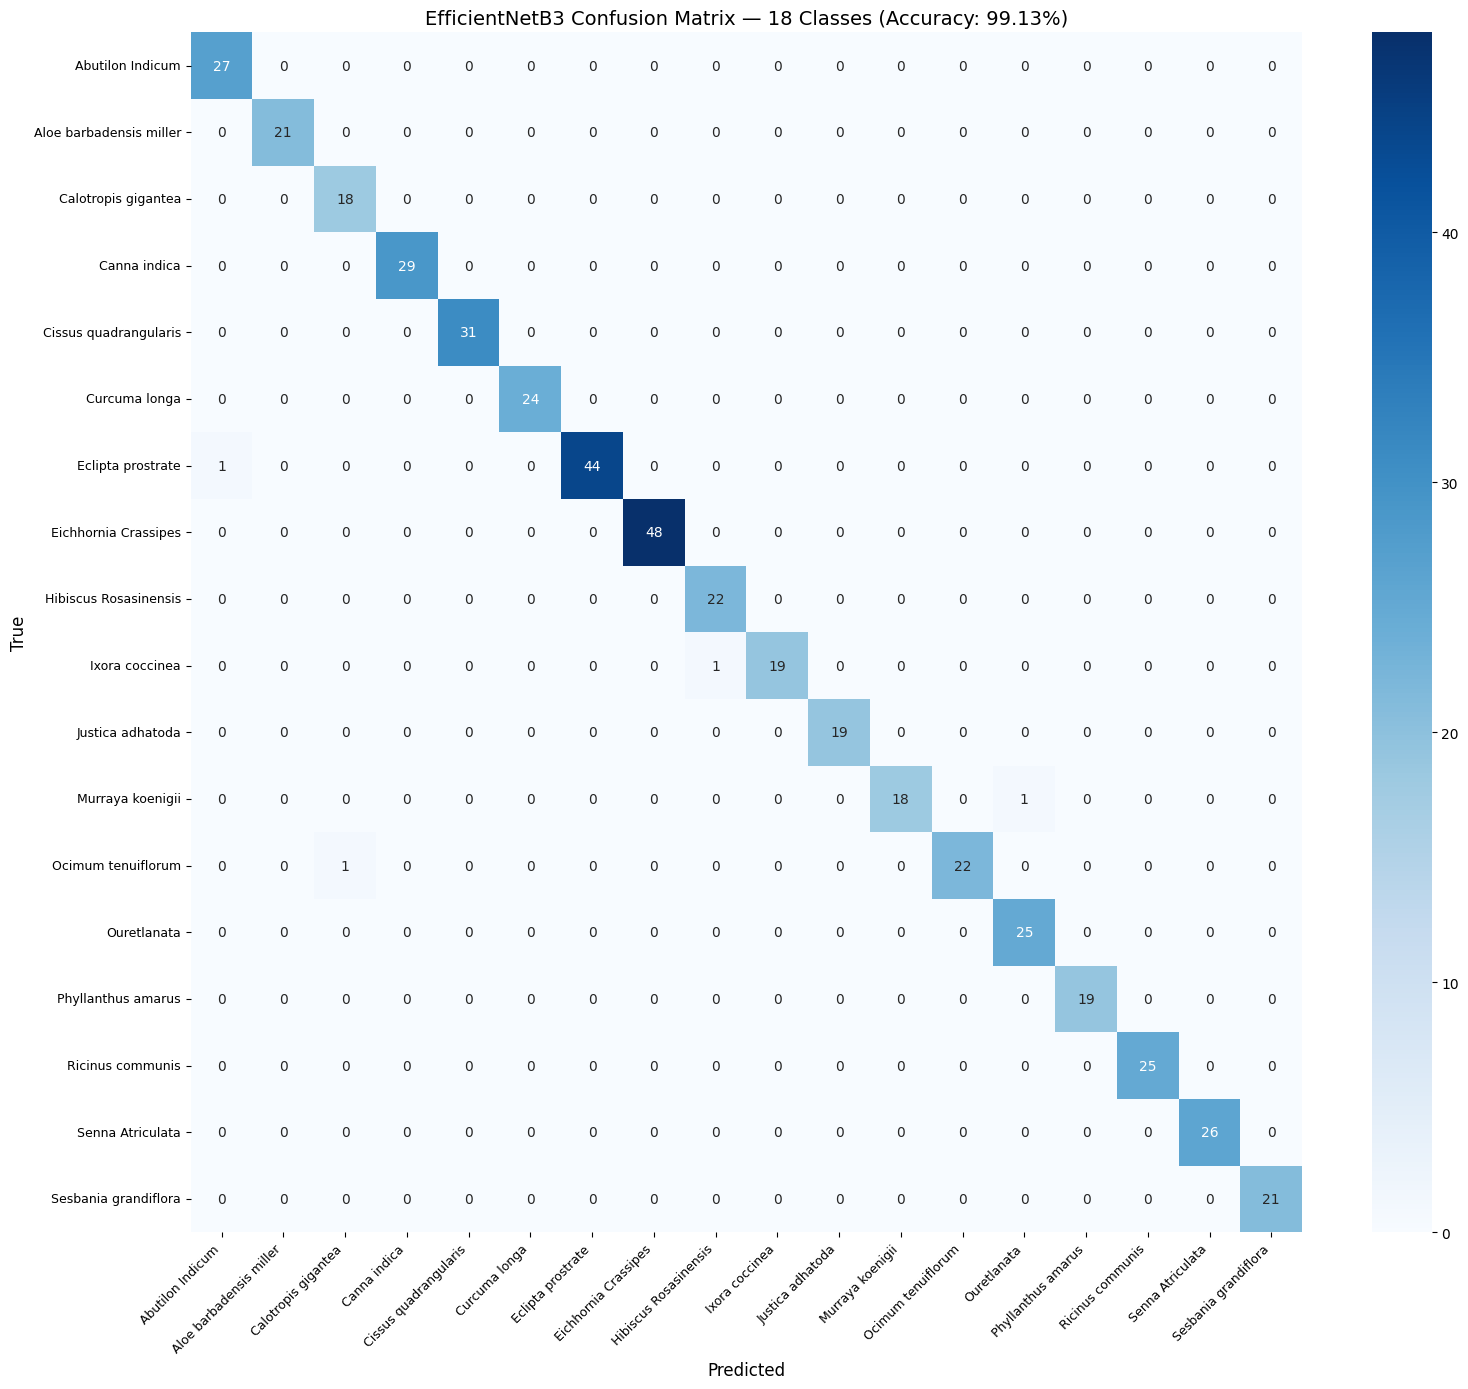

In [7]:
# Confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all, labels=range(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'EfficientNetB3 Confusion Matrix — 18 Classes (Accuracy: {accuracy*100:.2f}%)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'efficientnet_18class_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

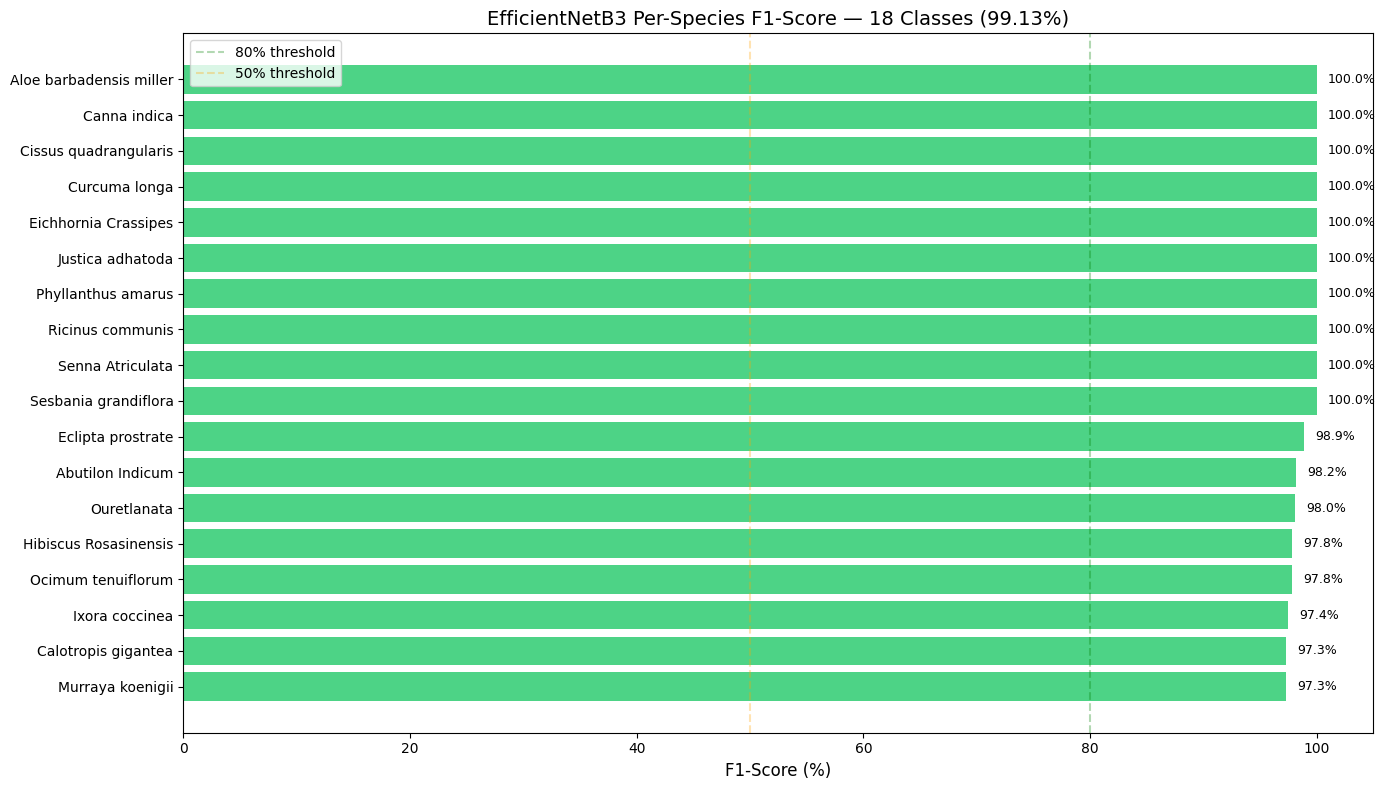

In [8]:
# Per-species F1 bar chart
species_f1 = {name: report_dict[name]['f1-score'] for name in class_names}
sorted_species = sorted(species_f1.items(), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(14, 8))
names = [s[0] for s in sorted_species]
f1s = [s[1]*100 for s in sorted_species]
colors = ['#2ecc71' if f >= 80 else '#f39c12' if f >= 50 else '#e74c3c' for f in f1s]
bars = ax.barh(range(len(names)), f1s, color=colors, alpha=0.85)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('F1-Score (%)', fontsize=12)
ax.set_title(f'EfficientNetB3 Per-Species F1-Score — 18 Classes ({accuracy*100:.2f}%)', fontsize=14)
ax.set_xlim(0, 105)
ax.invert_yaxis()
for bar, f1 in zip(bars, f1s):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{f1:.1f}%', va='center', fontsize=9)
ax.axvline(x=80, color='green', linestyle='--', alpha=0.3, label='80% threshold')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.3, label='50% threshold')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'efficientnet_18class_f1_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5. Save Corrected Metrics

Overwrites the broken `improved_species_metrics.json` with correct per-species metrics.

In [9]:
# Build corrected metrics in same format as NB06's output
corrected_metrics = {}
for name in class_names:
    corrected_metrics[name] = {
        'precision': float(report_dict[name]['precision']),
        'recall': float(report_dict[name]['recall']),
        'f1-score': float(report_dict[name]['f1-score']),
        'support': float(report_dict[name]['support'])
    }

corrected_metrics['accuracy'] = float(accuracy)
corrected_metrics['macro avg'] = {
    'precision': float(report_dict['macro avg']['precision']),
    'recall': float(report_dict['macro avg']['recall']),
    'f1-score': float(report_dict['macro avg']['f1-score']),
    'support': float(report_dict['macro avg']['support'])
}
corrected_metrics['weighted avg'] = {
    'precision': float(report_dict['weighted avg']['precision']),
    'recall': float(report_dict['weighted avg']['recall']),
    'f1-score': float(report_dict['weighted avg']['f1-score']),
    'support': float(report_dict['weighted avg']['support'])
}

# Save to results directory
results_path = os.path.join(RESULTS_DIR, 'improved_species_metrics.json')
with open(results_path, 'w') as f:
    json.dump(corrected_metrics, f, indent=2)
print(f"Saved corrected metrics: {results_path}")

# Also overwrite the broken file in models directory
models_path = os.path.join(MODEL_DIR, 'improved_species_metrics.json')
with open(models_path, 'w') as f:
    json.dump(corrected_metrics, f, indent=2)
print(f"Overwrote broken metrics: {models_path}")

# Save full results with comparison data
full_results = {
    'model': 'EfficientNetB3',
    'input_size': '300x300',
    'accuracy_18class': float(accuracy),
    'total_samples': int(len(y_true_all)),
    'correct': int(np.sum(y_true_all == y_pred_all)),
    'num_classes': NUM_CLASSES,
    'weighted_precision': float(report_dict['weighted avg']['precision']),
    'weighted_recall': float(report_dict['weighted avg']['recall']),
    'weighted_f1': float(report_dict['weighted avg']['f1-score']),
    'macro_precision': float(report_dict['macro avg']['precision']),
    'macro_recall': float(report_dict['macro avg']['recall']),
    'macro_f1': float(report_dict['macro avg']['f1-score']),
    'per_species': {
        name: {
            'precision': float(report_dict[name]['precision']),
            'recall': float(report_dict[name]['recall']),
            'f1': float(report_dict[name]['f1-score']),
            'support': int(report_dict[name]['support'])
        }
        for name in class_names
    },
    'note': 'Corrected evaluation — NB06 had shuffle=False bug giving only 5 classes'
}

full_path = os.path.join(RESULTS_DIR, 'efficientnet_18class_metrics.json')
with open(full_path, 'w') as f:
    json.dump(full_results, f, indent=2)
print(f"Saved full results: {full_path}")

Saved corrected metrics: /content/drive/MyDrive/MedicinalPlant_Dissertation/efficientnet_eval_results/improved_species_metrics.json
Overwrote broken metrics: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/improved_species_metrics.json
Saved full results: /content/drive/MyDrive/MedicinalPlant_Dissertation/efficientnet_eval_results/efficientnet_18class_metrics.json


In [10]:
# Download corrected metrics file
from google.colab import files

print("\nFiles saved to Google Drive:")
print(f"  Corrected metrics: {models_path}")
print(f"  Full results: {full_path}")
print(f"  Confusion matrix: {os.path.join(RESULTS_DIR, 'efficientnet_18class_confusion_matrix.png')}")
print(f"  F1 chart: {os.path.join(RESULTS_DIR, 'efficientnet_18class_f1_distribution.png')}")

print("\nDownloading corrected metrics...")
files.download(results_path)
files.download(full_path)


Files saved to Google Drive:
  Corrected metrics: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/improved_species_metrics.json
  Full results: /content/drive/MyDrive/MedicinalPlant_Dissertation/efficientnet_eval_results/efficientnet_18class_metrics.json
  Confusion matrix: /content/drive/MyDrive/MedicinalPlant_Dissertation/efficientnet_eval_results/efficientnet_18class_confusion_matrix.png
  F1 chart: /content/drive/MyDrive/MedicinalPlant_Dissertation/efficientnet_eval_results/efficientnet_18class_f1_distribution.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>